# Weather Sounding

In [62]:
import matplotlib.pyplot as plt
import pandas as pd 
import os 
import numpy as np
from datetime import datetime

import metpy.calc as mpcalc
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from metpy.units import units


In [2]:
payload_data = os.path.join("data", "payload_data.csv")
pnc_data = os.path.join("data", "pnc_data.csv")
aprs_data = os.path.join("data", "aprsfi_export_KA7NSR-7.csv")

In [3]:
pay = pd.read_csv(payload_data)
aprs = pd.read_csv(aprs_data)

# rename pcfs 
pay = pay.rename(columns={
        "PCF8523 Year": "year",
        "PCF8523 Month": "month",
        "PCF8523 Day": "day",
        "PCF8523 Hour": "hour",
        "PCF8523 Minute": "minute",
        "PCF8523 Second": "second"
    })
display(pay["year"].dtype)

dtype('float64')

In [43]:
# get timestamped data from sources
# payload 
def parse_pay_dt(row):
    try:
        return pd.Timestamp(
            year=int(row["year"]), 
            month=int(row["month"]),
            day=int(row["day"]), 
            hour=int(row["hour"]),
            minute=int(row["minute"]),
            second=int(row["second"])
        ).tz_localize("America/Phoenix")
    except:
        return pd.NaT
        
pay["timestamp"] = pay.apply(parse_pay_dt, axis=1)
pay["timestamp"] = pd.to_datetime(pay["timestamp"])

from time import sleep 
# estimate missing timestamps from millis
for it, row in pay.iterrows():
    if pd.isna(row["timestamp"]): # missing try to replace
        # print(f"trying to fix row {it}")
        new_ts = pd.NaT
        offset = 1
        while pd.isna(new_ts):
            # sleep(1)
            # print("offset", offset)
            before_ts = pay.iloc[max(it-offset,0)]["timestamp"] + pd.Timedelta(
                        milliseconds = row["Millis"] - pay.iloc[it-offset]["Millis"])
            after_ts = pay.iloc[min(it+offset, len(pay))]["timestamp"] - pd.Timedelta(
                        milliseconds = pay.iloc[it+offset]["Millis"] - row["Millis"])
            
            if pd.notna(before_ts):
                # print("using", it-offset, before_ts)
                new_ts = before_ts
                break
            if pd.notna(after_ts):
                new_ts = after_ts
                # print("using", it+offset, after_ts)
                break
            offset += 1
            if offset > 5: break
        pay.loc[it, "timestamp"] = new_ts

dips = 0
for i in range(1,len(pay)): 
    if pay["timestamp"][i-1] > pay["timestamp"][i]: 
        print(i, pay["timestamp"][i-1], pay["timestamp"][i])
        pay.loc[i, "timestamp"] = pay["timestamp"][i-1] + pd.Timedelta(milliseconds=1)
        dips += 1
print(dips)

display(pay.columns)
display(aprs.columns)
# pay.plot(x="timestamp", y="Millis")
# plt.show()

aprs["timestamp"] = pd.to_datetime(aprs["time"], utc=True)
aprs["timestamp"] = aprs["timestamp"].dt.tz_convert('America/Phoenix')

display(pay["timestamp"].dtype, aprs["timestamp"].dtype)

# end 9:31:05
end_time = aprs["timestamp"][0]
end_time = end_time.replace(hour=9, minute=31, second=5)

# select aprs 
aprs = aprs[aprs["timestamp"] <= end_time]

1926 2026-03-28 09:29:29.216000-07:00 2026-03-28 09:29:29-07:00
1998 2026-03-28 09:30:36.694000-07:00 2026-03-28 09:30:36-07:00
2


Index(['Millis', 'PicoTemp Temp (C)', 'ICM20948 AccX (g)', 'ICM20948 AccY (g)',
       'ICM20948 AccZ (g)', 'ICM20948 GyroX (deg/s)', 'ICM20948 GyroY (deg/s)',
       'ICM20948 GyroZ (deg/s)', 'ICM20948 MagX (uT)', 'ICM20948 MagY (uT)',
       'ICM20948 MagZ (uT)', 'ICM20948 Temp (C)', 'year', 'month', 'day',
       'hour', 'minute', 'second', 'TMP117 Temp (C)', 'BME688 Temp (C)',
       'BME688 Pressure', 'BME688 Rel Hum (%)', 'BME688 Gas Resistance',
       'Geiger CPS', 'Geiger Dose (uSv/hr)', 'UV_Sensor_O UVA2 (nm)',
       'UV_Sensor_O UVB2 (nm)', 'UV_Sensor_O UVC2 (nm)', 'ENS160_O AQI',
       'ENS160_O TVOC (ppb)', 'ENS160_O eCO2 (ppm)', 'BMP390_O Temp (C)',
       'BMP390_O Pressure (Pa)', 'BMP390_O Altitude (m)',
       'TMP117_O Temp_O (C)', 'SHTC3_O Temp (C)', 'SHTC3_O Rel Hum (%)',
       'Ozone Conc (ppb)', 'AnalogTemp ADC_Read', 'timestamp'],
      dtype='str')

Index(['time', 'lasttime', 'lat', 'lng', 'speed', 'course', 'altitude',
       'comment', 'timestamp'],
      dtype='str')

datetime64[us, America/Phoenix]

datetime64[us, America/Phoenix]

In [92]:
# build synced lists out of the dataframe 
merged = pd.merge_asof(
    aprs, 
    pay, 
    on="timestamp",
    direction="nearest",
    tolerance=pd.Timedelta("60s"))

print("Using", len(merged), " merged datapoints")

pres_col = "BME688 Pressure"
temp_col = "TMP117_O Temp_O (C)"
hum_col = "SHTC3_O Rel Hum (%)"
ws_col = "speed"
wd_col = "course"

# pressure - payload 
pressure = []
# temperature - payload
temperature = []
# relative humidity - payload
humidity = []

# wind speed (heading) - aprs 
wind_pressure = []
wind_speed = []
wind_direction = [] 

# populate list with complete rows
clean_pay = pay[[pres_col, temp_col, hum_col]].dropna()
# pressure = clean_pay[pres_col]
# temperature = clean_pay[temp_col]
# humidity = clean_pay[hum_col]
last_pressure = 1_000_000 # arbitrarily high 
for it, row in clean_pay.iterrows():
    if row[pres_col] < last_pressure:
        last_pressure = row[pres_col]
        pressure.append(row[pres_col])
        temperature.append(row[temp_col])
        humidity.append(row[hum_col])

# populate wind data 
for it, row in merged.iterrows():
    # check the values exist
    if pd.notna(row[pres_col]) and pd.notna(row[ws_col]) and pd.notna(row[wd_col]):
        wind_pressure.append(row[pres_col])
        wind_speed.append(row[ws_col])
        wind_direction.append(row[wd_col])
        
# add units
pres = np.array(pressure) * units.Pa 
temp = np.array(temperature) * units.degC
rel_hum = np.array(humidity) * units.percent
wind_pressure = np.array(wind_pressure) * units.Pa
wind_speed = np.array(wind_speed) * units("km/hr")
wind_direction = np.array(wind_direction) * units.deg

# calculate dewpoint 
dewpoint = mpcalc.dewpoint_from_relative_humidity(temp, rel_hum)

# calculate wind components 
u, v = mpcalc.wind_components(wind_speed, wind_direction)

print("Data Counts:")
print("Pressure/Temperature/DewPoint:", len(temp), "| Pressure max:", np.max(pres))
print("Wind Pressure/Speed/Direction:", len(wind_pressure))

Using 30  merged datapoints
Data Counts:
Pressure/Temperature/DewPoint: 1676 | Pressure max: 97002.0 pascal
Wind Pressure/Speed/Direction: 30


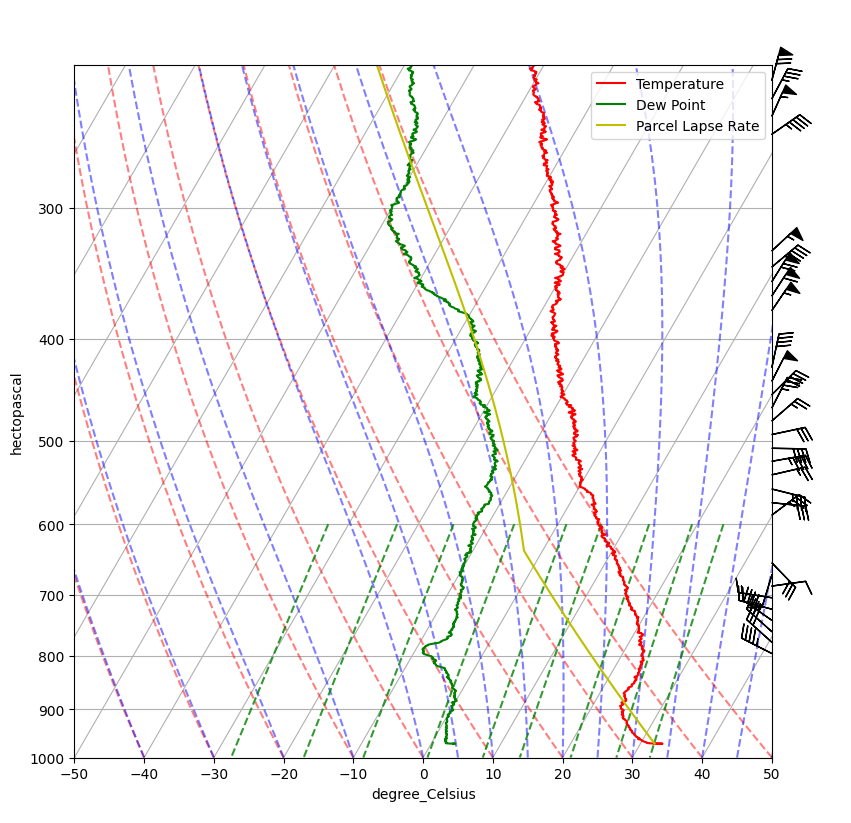

In [93]:
# plot
fig = plt.figure(figsize = (9,9))
skew = SkewT(fig=fig, aspect='auto')

prof = mpcalc.parcel_profile(pres, temp[0], dewpoint[0]).to('degC')

skew.plot(pres, temp, 'r')
skew.plot(pres, dewpoint, 'g')
skew.plot(pres, prof, 'y')
skew.plot_barbs(wind_pressure, u, v)

skew.ax.set_xlim(-50, 50)
skew.ax.set_ylim(1000, min(pres))

skew.plot_dry_adiabats()
skew.plot_moist_adiabats()
skew.plot_mixing_lines()

plt.legend(("Temperature","Dew Point", 
            "Parcel Lapse Rate"), 
           shadow=False, 
           fancybox=True, 
           bbox_to_anchor = [1, 1]) #Legend providing same color for both


plt.show()